# CNN Baseline Model

This notebook trains a simple convolutional neural network as a baseline model for blood cell image classification.

In [6]:
from pathlib import Path
import sys

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

In [7]:
sys.path.append("..")

from src.data import get_dataloaders

In [8]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [9]:
dataset_path = Path(
    "/Users/amirhossein/.cache/kagglehub/datasets/"
    "unclesamulus/blood-cells-image-dataset/"
    "versions/2/bloodcells_dataset"
)

train_loader, val_loader, test_loader, class_names = get_dataloaders(
    dataset_path=dataset_path,
    image_size=224,
    batch_size=16
)

class_names

['basophil',
 'eosinophil',
 'erythroblast',
 'ig',
 'lymphocyte',
 'monocyte',
 'neutrophil',
 'platelet']

In [10]:
# Check batch
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([16, 3, 224, 224])
torch.Size([16])


In [11]:
class SimpleCNN(nn.Module):
    
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.3), # Randomly trutns off 30% of neurons during training
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [12]:
num_classes = len(class_names)

model = SimpleCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=8, bias=True)
  )
)

In [13]:
num_epochs = 3

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    
    model.train()
    running_train_loss = 0.0
    
    for images, labels in train_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
    
    train_loss = running_train_loss / len(train_loader)
    train_losses.append(train_loss)
    
    
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        
        for images, labels in val_loader:
            
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss = running_val_loss / len(val_loader)
    val_accuracy = correct / total
    
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch [1/3] Train Loss: 0.7193 Val Loss: 0.4168 Val Accuracy: 0.8389
Epoch [2/3] Train Loss: 0.3066 Val Loss: 0.2283 Val Accuracy: 0.9193
Epoch [3/3] Train Loss: 0.2333 Val Loss: 0.2627 Val Accuracy: 0.9044


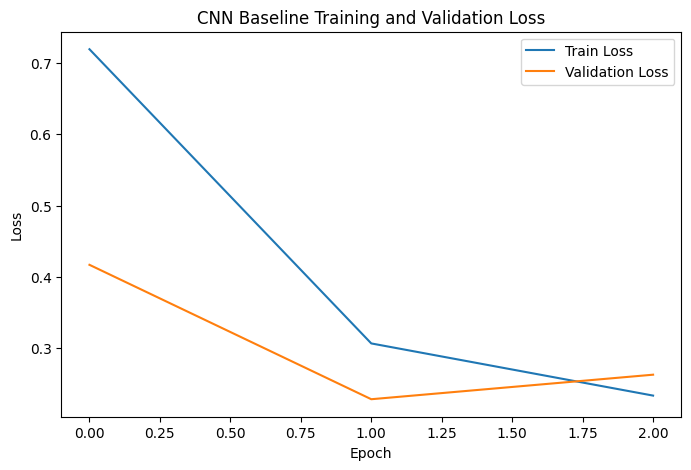

In [14]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Baseline Training and Validation Loss")
plt.legend()

plt.show()

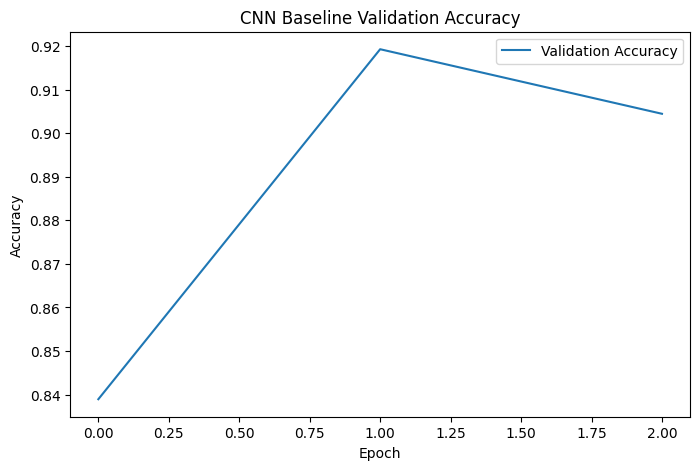

In [15]:
plt.figure(figsize=(8,5))

plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Baseline Validation Accuracy")
plt.legend()

plt.show()

In [16]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    
    for images, labels in test_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [17]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    basophil       0.98      0.78      0.87       183
  eosinophil       1.00      1.00      1.00       467
erythroblast       0.96      0.92      0.94       233
          ig       0.74      0.94      0.83       434
  lymphocyte       0.78      0.97      0.87       182
    monocyte       0.93      0.76      0.83       213
  neutrophil       0.99      0.86      0.92       500
    platelet       0.99      0.99      0.99       352

    accuracy                           0.91      2564
   macro avg       0.92      0.90      0.90      2564
weighted avg       0.93      0.91      0.91      2564



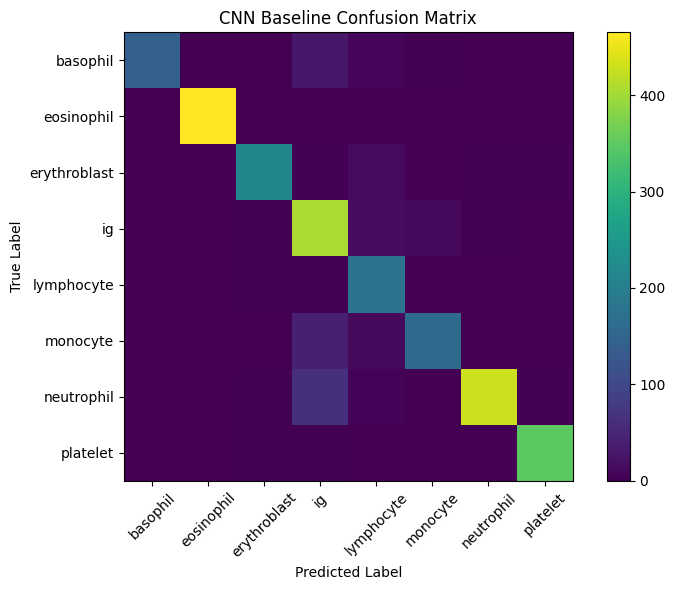

In [18]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("CNN Baseline Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

plt.colorbar()
plt.tight_layout()
plt.show()

## CNN Baseline Analysis

### Training Performance

The CNN baseline model was trained for 3 epochs on the blood cell classification dataset.

Training loss decreased consistently:

| Epoch | Train Loss |
|---------|---------|
| 1 | 0.719 |
| 2 | 0.307 |
| 3 | 0.233 |

This indicates that the model successfully learned meaningful visual features from the blood cell images.

### Validation Performance

Validation accuracy improved substantially during training:

| Epoch | Validation Accuracy |
|---------|---------|
| 1 | 83.89% |
| 2 | 91.93% |
| 3 | 90.44% |

The highest validation accuracy was achieved during Epoch 2 (91.93%).

Validation loss decreased from Epoch 1 to Epoch 2 and increased slightly during Epoch 3. This suggests that mild overfitting may begin after Epoch 2.

### Test Set Performance

The final CNN achieved:

- Test Accuracy: 0.91
- Macro F1-score: 0.90
- Weighted F1-score: 0.91

These results demonstrate that even a relatively simple CNN architecture is capable of accurately distinguishing between the eight blood cell categories.

### Per-Class Performance

Several classes were classified almost perfectly:

| Class | F1-score |
|---------|---------|
| eosinophil | 1.00 |
| platelet | 0.99 |
| erythroblast | 0.94 |
| neutrophil | 0.92 |

These cell types appear to possess highly distinctive visual characteristics that are easily recognized by the CNN.

More challenging classes included:

| Class | F1-score |
|---------|---------|
| ig | 0.83 |
| monocyte | 0.83 |
| basophil | 0.87 |
| lymphocyte | 0.87 |

These classes likely share morphological similarities with other white blood cell types, leading to increased confusion.

### Confusion Matrix Analysis

The confusion matrix reveals that most predictions lie along the main diagonal, indicating strong classification performance.

The largest source of error occurs among:

- Immature granulocytes (IG)
- Neutrophils
- Monocytes

This behavior is biologically reasonable because these cell types exhibit similar nuclear structures and granulation patterns under microscopy.

### Conclusions

The CNN baseline provides a strong benchmark for this project, achieving approximately 91% test accuracy.

While the model performs well, several classes remain difficult to separate. In the next stage, transfer learning with ResNet50 will be investigated to determine whether deeper pretrained architectures can improve classification performance and reduce confusion among visually similar cell types.

## CNN Final Results

Best Validation Accuracy: 0.9193

Test Accuracy: 0.91

Macro F1-score: 0.90

Weighted F1-score: 0.91